### Installation Instruction

`cd "C:\Users\YourName\Documents\MyProject"`
<br>
`python -m venv .venv` <br>
```
# For PowerShell:
.\venv\Scripts\Activate.ps1

# For Command Prompt:
.\venv\Scripts\activate
```

<br>

```
# Update pip first
python -m pip install --upgrade pip

# Install PyTorch (CPU version for simplicity, or visit pytorch.org for CUDA)
pip install torch torchvision matplotlib

# Install Jupyter and the Kernel bridge
pip install jupyter ipykernel
```

<br>

`python -m ipykernel install --user --name=my-env --display-name "Python-ENV"`

<br>

`jupyter notebook`

## Lab 7 \: BN vs Dropout
Use the CIFAR dataset to build a deep neural network model and analyze the effect of batch normalization and dropout

In [ ]:
import torch, torch.nn as nn, torchvision
from torchvision import transforms

# Small Data (only 2000 samples)
t = transforms.ToTensor()
trainset = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=t)
testset  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=t)

train = torch.utils.data.DataLoader(torch.utils.data.Subset(trainset, range(10000)), batch_size=64, shuffle=True)
test  = torch.utils.data.DataLoader(torch.utils.data.Subset(testset, range(5000)), batch_size=64)

# Tiny Model
class Net(nn.Module):
    def __init__(self, bn=False, do=False):
        super().__init__()
        self.c = nn.Conv2d(3,16,3,1,1)
        self.bn = nn.BatchNorm2d(16) if bn else nn.Identity()
        self.pool = nn.MaxPool2d(2,2)
        self.drop = nn.Dropout(0.3) if do else nn.Identity()
        self.fc = nn.Linear(16*16*16,10)

    def forward(self,x):
        x = self.pool(torch.relu(self.bn(self.c(x))))
        x = self.drop(x)
        x = x.view(-1,16*16*16)
        return self.fc(x)

# Train + Test
def run(name, model, epochs):
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(epochs):
        for x,y in train:
            opt.zero_grad()
            loss_fn(model(x),y).backward()
            opt.step()

    correct = total = 0
    with torch.no_grad():
        for x,y in test:
            pred = model(x).argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)

    print(name, "Acc:", correct/total)

# Experiments
run("Base", Net(), epochs=5)
run("BatchNorm", Net(bn=True), epochs=5)
run("Dropout", Net(do=True), epochs=5)
run("BN+Dropout", Net(bn=True, do=True), epochs=5)

Base Acc: 0.503
BatchNorm Acc: 0.5406
Dropout Acc: 0.4912
BN+Dropout Acc: 0.5214


## Lab 8 \: Optimizer Comparison

Implement a simple Convolutional Neural Network (CNN) and compare the performance of any two optimizers on the given image dataset

100%|██████████| 9.91M/9.91M [00:00<00:00, 134MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 18.8MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 118MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.14MB/s]


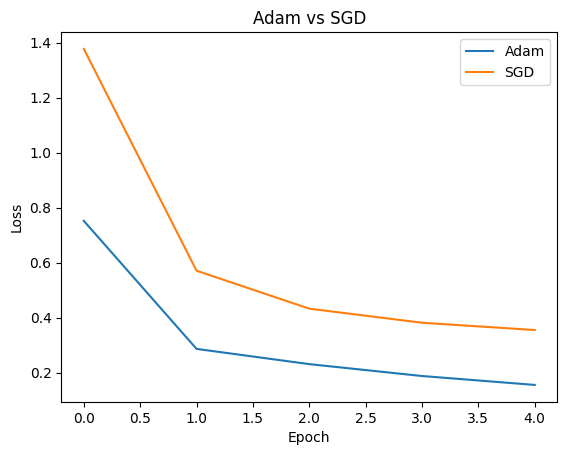

In [ ]:
import torch, torch.nn as nn, torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

# Small dataset
t = transforms.ToTensor()
data = torchvision.datasets.MNIST('./data', train=True, download=True, transform=t)
loader = torch.utils.data.DataLoader(torch.utils.data.Subset(data, range(10000)), batch_size=256, shuffle=True)

# Model
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.c = nn.Conv2d(1,16,3)
        self.p = nn.MaxPool2d(2)
        self.f = nn.Linear(16*13*13,10)

    def forward(self,x):
        x = self.p(torch.relu(self.c(x)))
        return self.f(x.view(-1,16*13*13))

# Train function
def run(opt_name):
    m = Net()
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(m.parameters(),0.001) if opt_name=='Adam' \
          else torch.optim.SGD(m.parameters(),0.01)

    hist = []
    for _ in range(5):   # 5 epochs
        total_loss = 0
        for x,y in loader:
            opt.zero_grad()
            loss = loss_fn(m(x),y)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        hist.append(total_loss/len(loader))
    return hist

# Run
adam = run('Adam')
sgd = run('SGD')

# Plot
plt.plot(adam,label='Adam')
plt.plot(sgd,label='SGD')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adam vs SGD")
plt.show()

## Lab 9 \: LeNet

Implement the LeNet architecture using a deep learning framework and apply it to the given image classification task

In [ ]:
import torch, torch.nn as nn, torchvision
from torchvision import transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data
t = transforms.Compose([transforms.Resize(32), transforms.ToTensor()])
train = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data', train=True, download=True, transform=t),
    batch_size=128, shuffle=True)

test = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data', train=False, download=True, transform=t),
    batch_size=128)

# Model (LeNet-5)
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.m = nn.Sequential(
            nn.Conv2d(1,6,5), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(6,16,5), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(16*5*5,120), nn.ReLU(),
            nn.Linear(120,84), nn.ReLU(),
            nn.Linear(84,10)
        )

    def forward(self,x): return self.m(x)

# Train
model = Net().to(device)
opt = torch.optim.Adam(model.parameters(), 0.001)
loss_fn = nn.CrossEntropyLoss()

for e in range(5):
    correct = total = loss = 0
    for x,y in train:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        l = loss_fn(out,y)
        l.backward(); opt.step()
        loss += l.item()
        correct += (out.argmax(1)==y).sum().item()
        total += y.size(0)
    print(f"Epoch {e+1} Loss:{loss/len(train):.4f} Acc:{100*correct/total:.2f}%")

# Test
model.eval()
correct = total = 0
with torch.no_grad():
    for x,y in test:
        x,y = x.to(device), y.to(device)
        correct += (model(x).argmax(1)==y).sum().item()
        total += y.size(0)

print("Test Acc:", 100*correct/total)

Starting Training on cpu...
Epoch 1 | Loss: 0.2141 | Acc: 93.52%
Epoch 2 | Loss: 0.0657 | Acc: 97.92%
Epoch 3 | Loss: 0.0464 | Acc: 98.53%
Epoch 4 | Loss: 0.0370 | Acc: 98.83%
Epoch 5 | Loss: 0.0318 | Acc: 99.00%
Test Accuracy: 98.81%
Finished!


## Lab 10 \: AlexNet

Implement the AlexNet architecture using a deep learning framework and apply it to the given image classification task

In [1]:
import torch, torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data transform
t = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=t)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=t)

train_indices = torch.randperm(len(trainset))[:15000] # 1 ≤ N ≤ 50000
test_indices  = torch.randperm(len(testset))[:1000] # 1 ≤ N ≤ 10000

trainset = Subset(trainset, train_indices)
testset  = Subset(testset, test_indices)

train_loader = DataLoader(trainset, batch_size=512, shuffle=True)
test_loader  = DataLoader(testset, batch_size=128, shuffle=False)

# AlexNet
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(3,96,11,4,2), nn.ReLU(), nn.MaxPool2d(3,2),
            nn.Conv2d(96,256,5,1,2), nn.ReLU(), nn.MaxPool2d(3,2),
            nn.Conv2d(256,384,3,1,1), nn.ReLU(),
            nn.Conv2d(384,384,3,1,1), nn.ReLU(),
            nn.Conv2d(384,256,3,1,1), nn.ReLU(), nn.MaxPool2d(3,2)
        )

        # automatically infer size
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024,1024),
            nn.ReLU(),
            nn.Linear(1024,10)
        )

    def forward(self,x):
        return self.fc(self.f(x))

model = Net().to(device)
opt = torch.optim.Adam(model.parameters(),0.001)
loss_fn = nn.CrossEntropyLoss()

# Train
for e in range(3):
    total_loss = 0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {e+1}, Loss: {total_loss/len(train_loader):.4f}")

# Test
model.eval()
correct = total = 0
with torch.no_grad():
    for x,y in test_loader:
        x,y = x.to(device), y.to(device)
        correct += (model(x).argmax(1)==y).sum().item()
        total += y.size(0)

print("Test Acc:", correct/total)

100%|██████████| 170M/170M [07:04<00:00, 402kB/s]


Epoch 1, Loss: 2.2869
Epoch 2, Loss: 2.0847
Epoch 3, Loss: 1.8809
Test Acc: 0.32


## Lab 11 \: RNN

Demonstrate the concept of language modeling using RNN, which involves training model to predict the next word in a sequence of words

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. EXPANDED DATASET: Just add any words you want here!
text = "pytorch is great for building deep learning models and rnn models are fun"
words = text.split()
vocab = sorted(list(set(words)))
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for i, w in enumerate(vocab)}

# Prepare X (current word) and Y (next word)
input_seq = [word_to_idx[w] for w in words[:-1]]
target_seq = [word_to_idx[w] for w in words[1:]]

X = torch.LongTensor(input_seq).unsqueeze(1).to(device) # Shape: [N, 1]
Y = torch.LongTensor(target_seq).to(device)             # Shape: [N]

# 2. MODEL: Same structure, just scales automatically with vocab size
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out.squeeze(1)) # Flatten [N, 1, hidden] to [N, hidden]

model = RNNModel(len(vocab), 16, 32).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

# 3. TRAINING
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    loss = criterion(model(X), Y)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# 4. PREDICT
def predict(word):
    model.eval()
    idx = torch.LongTensor([[word_to_idx[word]]]).to(device)
    pred = model(idx).argmax(dim=1)
    return idx_to_word[pred.item()]

print(f"\nAfter 'pytorch' --> Prediction: '{predict('pytorch')}'")
print(f"After 'building' --> Prediction: '{predict('building')}'")

## Lab 12 \: LSTM


Implement an LSTM-based text generation model and train the model to generate text sequences.

In [ ]:
import torch, torch.nn as nn, torch.optim as optim

# Dummy data (replace with real text if needed)
text = "to be or not to be that is the question".split()
vocab = list(set(text))
w2i = {w:i for i,w in enumerate(vocab)}
i2w = {i:w for w,i in w2i.items()}

# Build sequences
seq_len = 3
X, Y = [], []
for i in range(len(text)-seq_len):
    X.append([w2i[w] for w in text[i:i+seq_len]])
    Y.append(w2i[text[i+seq_len]])

X, Y = torch.tensor(X), torch.tensor(Y)

# Model
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(len(vocab), 32)
        self.lstm = nn.LSTM(32, 64, batch_first=True)
        self.fc = nn.Linear(64, len(vocab))

    def forward(self, x):
        x = self.emb(x)
        x,_ = self.lstm(x)
        return self.fc(x[:,-1])

model = Model()
opt = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

# Train
for _ in range(50):
    opt.zero_grad()
    loss = loss_fn(model(X), Y)
    loss.backward()
    opt.step()

# Generate
def gen(seed, n=5):
    words = seed.split()
    for _ in range(n):
        x = torch.tensor([[w2i[w] for w in words[-seq_len:]]])
        y = model(x).argmax(1).item()
        words.append(i2w[y])
    return " ".join(words)

print(gen("to be or"))